# Performance Analytics — Bluestock Fintech Mutual Fund Project
**Day 4 — Quantitative Performance Analysis**  
**Author:** Bluestock Intern  
**Date:** 2025-06-04  

This notebook computes daily returns, CAGR, Sharpe ratio, Sortino ratio, Alpha, Beta, Maximum Drawdown, and a composite Fund Scorecard for all 40 schemes. Every metric is calculated from raw NAV data — not from pre-computed columns.

---

## 0. Setup — Libraries & Data

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

BASE      = r"C:\Users\Manis\OneDrive\Desktop\bluestock_mf_analysis"
CHART_DIR = os.path.join(BASE, "notebooks", "charts")
os.makedirs(CHART_DIR, exist_ok=True)

sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#b0b0b0",
    "ytick.color":      "#b0b0b0",
    "text.color":       "#e0e0e0",
    "grid.color":       "#2a2d3d",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
})

def save_fig(fig, name):
    path = os.path.join(CHART_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"  Saved: {path}")
    plt.show()

print("Libraries loaded OK")

Libraries loaded OK


In [2]:
PROC = os.path.join(BASE, "data", "processed")

nav_df   = pd.read_csv(os.path.join(PROC, "02_nav_history_clean.csv"),   parse_dates=["date"])
fund_df  = pd.read_csv(os.path.join(PROC, "01_fund_master_clean.csv"))
bench_df = pd.read_csv(os.path.join(PROC, "10_benchmark_indices_clean.csv"), parse_dates=["date"])
perf_ref = pd.read_csv(os.path.join(PROC, "07_scheme_performance_clean.csv"))

nav_df   = nav_df.sort_values(["amfi_code", "date"]).reset_index(drop=True)
latest   = nav_df["date"].max()

print(f"NAV data loaded  : {len(nav_df):,} rows | {nav_df['amfi_code'].nunique()} funds")
print(f"Date range       : {nav_df['date'].min().date()} to {latest.date()}")
print(f"Benchmark indices: {bench_df['index_name'].unique().tolist()}")

NAV data loaded  : 64,320 rows | 40 funds
Date range       : 2022-01-03 to 2026-05-29
Benchmark indices: ['BSE_SMALLCAP', 'CRISIL_GILT', 'CRISIL_LIQUID', 'NIFTY100', 'NIFTY50', 'NIFTY500', 'NIFTY_MIDCAP150']


---
## 1. Daily Returns

Daily return for each fund on each trading day is calculated as:

> **daily_return = (NAV_today / NAV_yesterday) − 1**

This is the standard percentage change formula. The first day of each fund has no return (NaN), which is expected.

In [3]:
nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()

print("Daily return distribution across all funds:")
print(nav_df["daily_return"].describe().round(6))
print()
print(f"Max single-day gain : {nav_df['daily_return'].max()*100:.2f}%")
print(f"Max single-day loss : {nav_df['daily_return'].min()*100:.2f}%")
print(f"Average daily return: {nav_df['daily_return'].mean()*100:.4f}%")
print()

# Sanity check — values should mostly be between -6% and +6%
extreme = nav_df[(nav_df["daily_return"].abs() > 0.06)].shape[0]
total   = nav_df["daily_return"].dropna().shape[0]
print(f"Extreme moves (>6% in a day): {extreme} out of {total:,} ({extreme/total*100:.2f}%)")
print("Distribution looks reasonable - small daily moves, rare extremes")

Daily return distribution across all funds:
count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

Max single-day gain : 6.47%
Max single-day loss : -5.81%
Average daily return: 0.0451%

Extreme moves (>6% in a day): 1 out of 64,280 (0.00%)
Distribution looks reasonable - small daily moves, rare extremes


  Saved: C:\Users\Manis\OneDrive\Desktop\bluestock_mf_analysis\notebooks\charts\PA_01_return_distribution.png


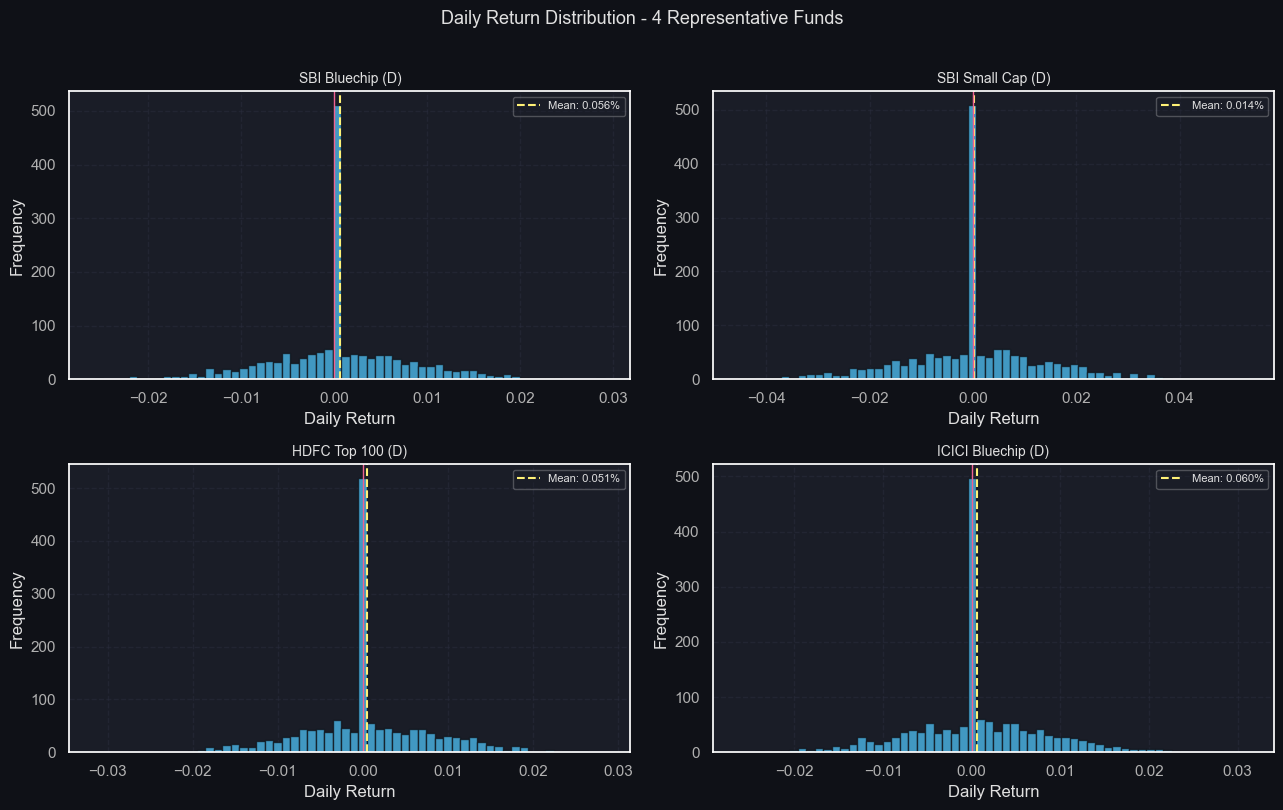

In [4]:
# Plot return distribution for 4 representative funds
sample_codes = [119552, 119599, 125497, 120504]
sample_names = {
    119552: "SBI Bluechip (D)",
    119599: "SBI Small Cap (D)",
    125497: "HDFC Top 100 (D)",
    120504: "ICICI Bluechip (D)",
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, code in enumerate(sample_codes):
    ret = nav_df[nav_df["amfi_code"]==code]["daily_return"].dropna()
    axes[i].hist(ret, bins=60, color="#4fc3f7", alpha=0.75, edgecolor="#0f1117")
    axes[i].axvline(ret.mean(), color="#fff176", linewidth=1.5, linestyle="--", label=f"Mean: {ret.mean()*100:.3f}%")
    axes[i].axvline(0, color="#f06292", linewidth=1, linestyle="-")
    axes[i].set_title(sample_names[code], fontsize=10)
    axes[i].set_xlabel("Daily Return")
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=8, framealpha=0.3)

fig.suptitle("Daily Return Distribution - 4 Representative Funds", fontsize=13, y=1.01)
plt.tight_layout()
save_fig(fig, "PA_01_return_distribution.png")

---
## 2. CAGR — Compounded Annual Growth Rate

CAGR measures how much a fund grew per year on a compounded basis:

> **CAGR = (NAV_end / NAV_start) ^ (1/n) − 1**

Where n = number of years. Since our data starts from Jan 2022, the maximum reliable history is ~4 years. We compute 1-year, 3-year, and since-inception CAGR.

In [5]:
RF_ANNUAL = 0.065          # RBI repo rate proxy (risk-free rate)
RF_DAILY  = RF_ANNUAL / 252

def get_nav_nearest(df, code, target_date):
    """Return NAV closest to target_date (on or before)."""
    sub = df[(df["amfi_code"]==code) & (df["date"] <= target_date)]
    return sub.sort_values("date").iloc[-1]["nav"] if len(sub) > 0 else None

def compute_cagr(nav_start, nav_end, years):
    if nav_start is None or nav_end is None or nav_start <= 0:
        return None
    return (nav_end / nav_start) ** (1 / years) - 1

cagr_rows = []
for code in nav_df["amfi_code"].unique():
    nav_end  = get_nav_nearest(nav_df, code, latest)
    nav_1yr  = get_nav_nearest(nav_df, code, latest - pd.DateOffset(years=1))
    nav_3yr  = get_nav_nearest(nav_df, code, latest - pd.DateOffset(years=3))
    nav_4yr  = get_nav_nearest(nav_df, code, latest - pd.DateOffset(years=4))

    cagr_rows.append({
        "amfi_code"  : code,
        "cagr_1yr"   : compute_cagr(nav_1yr, nav_end, 1),
        "cagr_3yr"   : compute_cagr(nav_3yr, nav_end, 3),
        "cagr_4yr"   : compute_cagr(nav_4yr, nav_end, 4),
    })

cagr_df = pd.DataFrame(cagr_rows).merge(
    fund_df[["amfi_code","scheme_name","sub_category","plan","fund_house"]], on="amfi_code", how="left")

print("CAGR computed for all funds:")
top5 = cagr_df.nlargest(5, "cagr_3yr")[["scheme_name","cagr_1yr","cagr_3yr","cagr_4yr"]]
top5.columns = ["Scheme", "1-Yr CAGR", "3-Yr CAGR", "4-Yr CAGR"]
for col in ["1-Yr CAGR","3-Yr CAGR","4-Yr CAGR"]:
    top5[col] = top5[col].map(lambda x: f"{x*100:.2f}%" if x else "N/A")
print(top5.to_string(index=False))

CAGR computed for all funds:
                                            Scheme 1-Yr CAGR 3-Yr CAGR 4-Yr CAGR
               Axis Midcap Fund - Regular - Growth    22.26%    35.11%    30.48%
     Mirae Asset Large Cap Fund - Regular - Growth    20.36%    34.00%    28.84%
         ICICI Pru Bluechip Fund - Direct - Growth    13.06%    32.49%    23.10%
HDFC Mid-Cap Opportunities Fund - Regular - Growth    53.23%    32.44%    37.24%
          ICICI Pru Midcap Fund - Regular - Growth    29.60%    31.78%    26.78%


  Saved: C:\Users\Manis\OneDrive\Desktop\bluestock_mf_analysis\notebooks\charts\PA_02_cagr_comparison.png


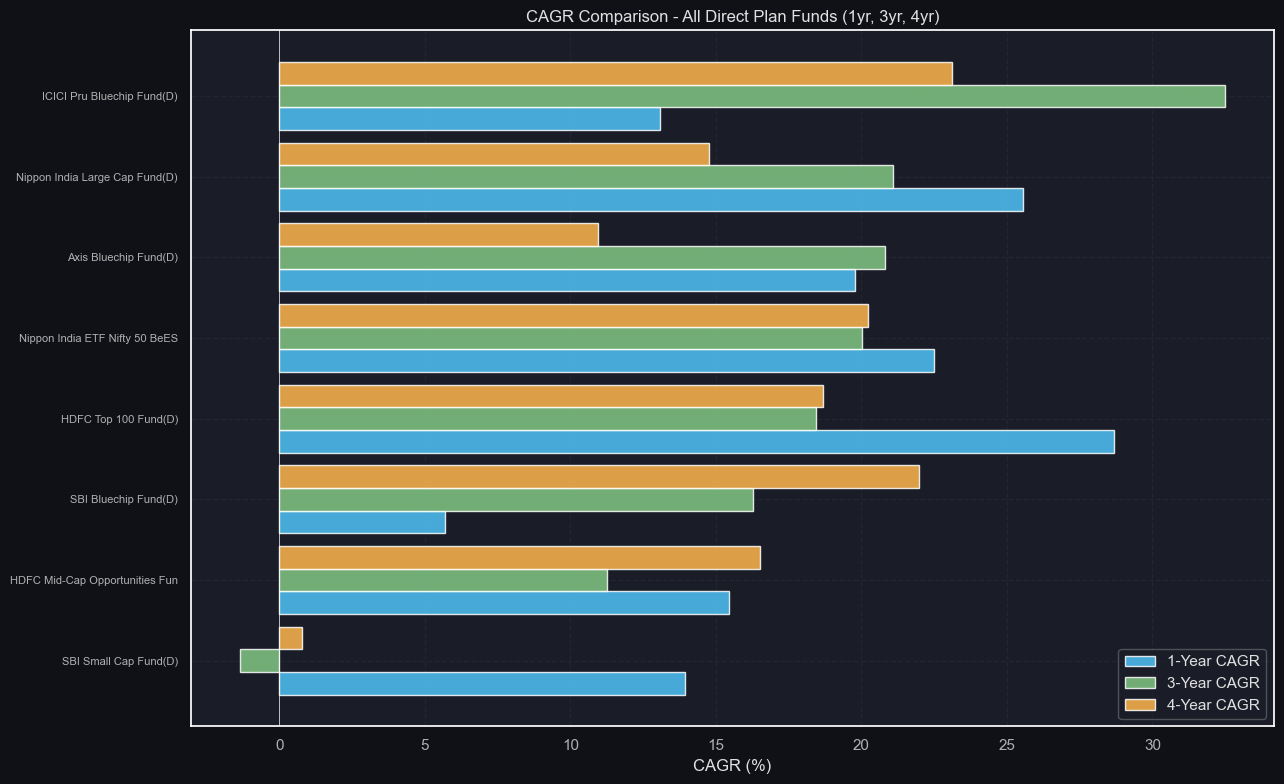

In [6]:
# CAGR comparison chart - Direct plans only
direct = cagr_df[cagr_df["plan"]=="Direct"].dropna(subset=["cagr_3yr"]).sort_values("cagr_3yr", ascending=True)
short_names = direct["scheme_name"].str.replace(" - Direct Plan - Growth","(D)").str.replace(" - Direct - Growth","(D)").str[:30]

fig, ax = plt.subplots(figsize=(13, 8))
y = np.arange(len(direct))
width = 0.28

bars1 = ax.barh(y - width, direct["cagr_1yr"]*100, width, color="#4fc3f7", alpha=0.85, label="1-Year CAGR")
bars2 = ax.barh(y,         direct["cagr_3yr"]*100, width, color="#81c784", alpha=0.85, label="3-Year CAGR")
bars3 = ax.barh(y + width, direct["cagr_4yr"]*100, width, color="#ffb74d", alpha=0.85, label="4-Year CAGR")

ax.set_yticks(y)
ax.set_yticklabels(short_names, fontsize=8)
ax.set_xlabel("CAGR (%)")
ax.set_title("CAGR Comparison - All Direct Plan Funds (1yr, 3yr, 4yr)", fontsize=12)
ax.axvline(0, color="white", linewidth=0.5)
ax.legend(framealpha=0.3)
plt.tight_layout()
save_fig(fig, "PA_02_cagr_comparison.png")

---
## 3. Sharpe Ratio

The Sharpe Ratio measures return earned per unit of total risk:

> **Sharpe = (Rp - Rf) / Std(Rp) x sqrt(252)**

Where Rp = average daily return, Rf = daily risk-free rate (6.5% / 252), and we multiply by sqrt(252) to annualise. A Sharpe above 1.0 is generally considered good.

In [7]:
sharpe_rows = []
for code in nav_df["amfi_code"].unique():
    ret = nav_df[nav_df["amfi_code"]==code]["daily_return"].dropna()
    if len(ret) < 50:
        sharpe_rows.append({"amfi_code": code, "sharpe": None})
        continue
    excess_ret = ret - RF_DAILY
    sharpe = (excess_ret.mean() / ret.std()) * np.sqrt(252)
    sharpe_rows.append({"amfi_code": code, "sharpe": round(sharpe, 4)})

sharpe_df = pd.DataFrame(sharpe_rows).merge(
    fund_df[["amfi_code","scheme_name","plan","sub_category"]], on="amfi_code", how="left")

print("Sharpe Ratio Rankings (Top 10):")
top10 = sharpe_df.nlargest(10, "sharpe")[["scheme_name","plan","sub_category","sharpe"]]
print(top10.to_string(index=False))
print()
print(f"Funds with Sharpe > 1.0 (good): {(sharpe_df['sharpe']>1).sum()}")
print(f"Funds with Sharpe < 0 (poor)  : {(sharpe_df['sharpe']<0).sum()}")

Sharpe Ratio Rankings (Top 10):
                                       scheme_name    plan sub_category  sharpe
     Mirae Asset Large Cap Fund - Regular - Growth Regular    Large Cap  1.0682
            Kotak Flexicap Fund - Regular - Growth Regular    Flexi Cap  0.9656
     Mirae Asset Tax Saver Fund - Regular - Growth Regular         ELSS  0.9190
          ICICI Pru Midcap Fund - Regular - Growth Regular      Mid Cap  0.8833
         SBI Bluechip Fund - Regular Plan - Growth Regular    Large Cap  0.8610
                DSP Midcap Fund - Regular - Growth Regular      Mid Cap  0.8329
HDFC Mid-Cap Opportunities Fund - Regular - Growth Regular      Mid Cap  0.8083
    Nippon India Large Cap Fund - Regular - Growth Regular    Large Cap  0.7589
               Axis Midcap Fund - Regular - Growth Regular      Mid Cap  0.7305
     ABSL Frontline Equity Fund - Regular - Growth Regular    Large Cap  0.7174

Funds with Sharpe > 1.0 (good): 1
Funds with Sharpe < 0 (poor)  : 13


  Saved: C:\Users\Manis\OneDrive\Desktop\bluestock_mf_analysis\notebooks\charts\PA_03_sharpe_ranking.png


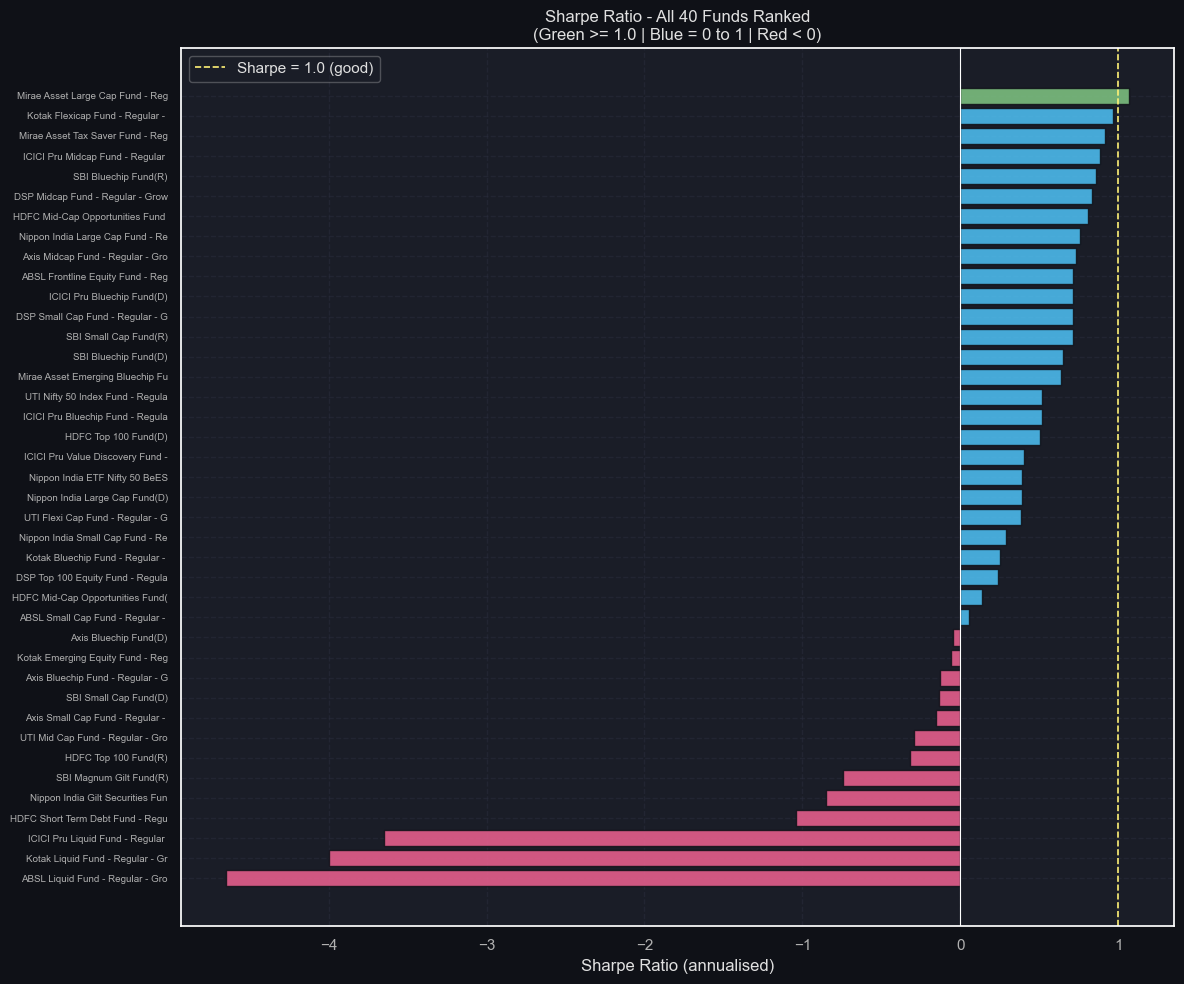

In [8]:
sharpe_plot = sharpe_df.dropna(subset=["sharpe"]).sort_values("sharpe")
short = sharpe_plot["scheme_name"].str.replace(" - Direct Plan - Growth","(D)").str.replace(" - Regular Plan - Growth","(R)").str.replace(" - Direct - Growth","(D)").str[:32]
colors = ["#f06292" if s < 0 else "#81c784" if s >= 1 else "#4fc3f7" for s in sharpe_plot["sharpe"]]

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(range(len(sharpe_plot)), sharpe_plot["sharpe"], color=colors, alpha=0.85, edgecolor="#0f1117")
ax.set_yticks(range(len(sharpe_plot)))
ax.set_yticklabels(short, fontsize=7)
ax.axvline(0,   color="white",   linewidth=0.8, linestyle="-")
ax.axvline(1.0, color="#fff176", linewidth=1.2, linestyle="--", label="Sharpe = 1.0 (good)")
ax.set_xlabel("Sharpe Ratio (annualised)")
ax.set_title("Sharpe Ratio - All 40 Funds Ranked\n(Green >= 1.0 | Blue = 0 to 1 | Red < 0)", fontsize=12)
ax.legend(framealpha=0.3)
plt.tight_layout()
save_fig(fig, "PA_03_sharpe_ranking.png")

---
## 4. Sortino Ratio

The Sortino Ratio is like Sharpe but only penalises downside risk:

> **Sortino = (Rp - Rf) / Std(negative returns only) x sqrt(252)**

This is a fairer measure for funds that are volatile on the upside (which investors don't mind) but stable on the downside.

In [9]:
sortino_rows = []
for code in nav_df["amfi_code"].unique():
    ret = nav_df[nav_df["amfi_code"]==code]["daily_return"].dropna()
    if len(ret) < 50:
        sortino_rows.append({"amfi_code": code, "sortino": None})
        continue
    excess_ret  = ret - RF_DAILY
    downside    = ret[ret < 0]
    down_std    = downside.std()
    sortino     = (excess_ret.mean() / down_std) * np.sqrt(252) if down_std > 0 else None
    sortino_rows.append({"amfi_code": code, "sortino": round(sortino, 4) if sortino else None})

sortino_df = pd.DataFrame(sortino_rows).merge(
    fund_df[["amfi_code","scheme_name","plan","sub_category"]], on="amfi_code", how="left")

print("Sortino Ratio Rankings (Top 10):")
top10s = sortino_df.nlargest(10, "sortino")[["scheme_name","plan","sub_category","sortino"]]
print(top10s.to_string(index=False))

Sortino Ratio Rankings (Top 10):
                                       scheme_name    plan sub_category  sortino
     Mirae Asset Large Cap Fund - Regular - Growth Regular    Large Cap   1.4907
            Kotak Flexicap Fund - Regular - Growth Regular    Flexi Cap   1.4795
     Mirae Asset Tax Saver Fund - Regular - Growth Regular         ELSS   1.3528
         SBI Bluechip Fund - Regular Plan - Growth Regular    Large Cap   1.2915
          ICICI Pru Midcap Fund - Regular - Growth Regular      Mid Cap   1.2858
                DSP Midcap Fund - Regular - Growth Regular      Mid Cap   1.1678
HDFC Mid-Cap Opportunities Fund - Regular - Growth Regular      Mid Cap   1.1442
    Nippon India Large Cap Fund - Regular - Growth Regular    Large Cap   1.0989
        SBI Small Cap Fund - Regular Plan - Growth Regular    Small Cap   1.0673
         ICICI Pru Bluechip Fund - Direct - Growth  Direct    Large Cap   1.0640


  Saved: C:\Users\Manis\OneDrive\Desktop\bluestock_mf_analysis\notebooks\charts\PA_04_sharpe_vs_sortino.png


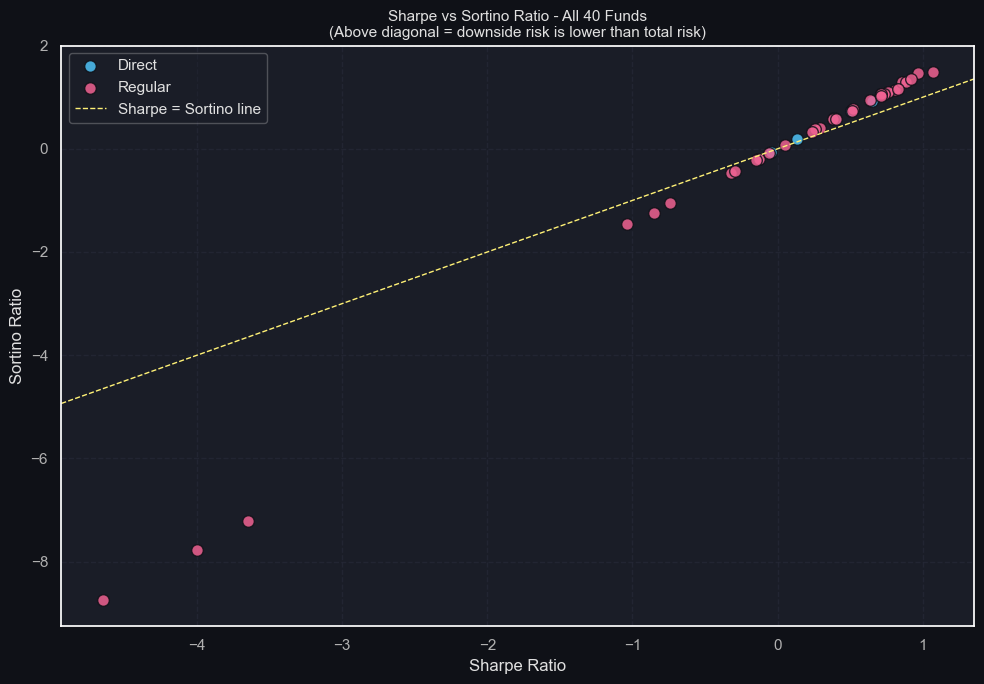

In [10]:
import matplotlib.pyplot as plt

# Sharpe vs Sortino scatter
combined = sharpe_df[["amfi_code", "sharpe"]].merge(
    sortino_df[["amfi_code", "sortino"]],
    on="amfi_code"
)

combined = combined.merge(
    fund_df[["amfi_code", "plan", "sub_category"]],
    on="amfi_code"
).dropna()

color_map = {
    "Direct": "#4fc3f7",
    "Regular": "#f06292"
}

fig, ax = plt.subplots(figsize=(10, 7))

for plan, grp in combined.groupby("plan"):
    ax.scatter(
        grp["sharpe"],
        grp["sortino"],
        label=plan,
        color=color_map.get(plan, "#ffffff"),
        s=70,
        alpha=0.85,
        edgecolors="#0f1117"
    )

# Reference line (Sharpe = Sortino)
ax.axline(
    (0, 0),
    slope=1,
    color="#fff176",
    linewidth=1,
    linestyle="--",
    label="Sharpe = Sortino line"
)

ax.set_xlabel("Sharpe Ratio")
ax.set_ylabel("Sortino Ratio")

ax.set_title(
    "Sharpe vs Sortino Ratio - All 40 Funds\n"
    "(Above diagonal = downside risk is lower than total risk)",
    fontsize=11
)

ax.legend(framealpha=0.3)

plt.tight_layout()

save_fig(fig, "PA_04_sharpe_vs_sortino.png")

plt.show()

---
## 5. Alpha and Beta (OLS Regression)

We use linear regression of fund daily returns against NIFTY 100 daily returns:

> **fund_return = Alpha + Beta x benchmark_return + error**

- **Beta** measures how much the fund moves when the market moves 1%
- **Alpha** (annualised) measures the fund manager's value-add above what market exposure alone would explain
- A positive Alpha means the fund manager is genuinely adding value

In [11]:
n100 = bench_df[bench_df["index_name"]=="NIFTY100"].sort_values("date").copy()
n100["bench_return"] = n100["close_value"].pct_change()
n100 = n100[["date","bench_return"]].dropna()

ab_rows = []
for code in nav_df["amfi_code"].unique():
    fund_ret = nav_df[nav_df["amfi_code"]==code][["date","daily_return"]].dropna()
    merged   = fund_ret.merge(n100, on="date").dropna()

    if len(merged) < 50:
        ab_rows.append({"amfi_code": code, "alpha": None, "beta": None, "r_squared": None})
        continue

    slope, intercept, r_val, p_val, std_err = stats.linregress(
        merged["bench_return"], merged["daily_return"])

    ab_rows.append({
        "amfi_code" : code,
        "beta"      : round(slope, 4),
        "alpha"     : round(intercept * 252, 4),   # annualised
        "r_squared" : round(r_val**2, 4),
    })

ab_df = pd.DataFrame(ab_rows).merge(
    fund_df[["amfi_code","scheme_name","plan","sub_category","fund_house"]], on="amfi_code", how="left")

print("Alpha & Beta - Top 10 by Alpha:")
print(ab_df.nlargest(10,"alpha")[["scheme_name","plan","alpha","beta","r_squared"]].to_string(index=False))
print()
print("Funds with Beta > 1 (more volatile than market):", (ab_df["beta"]>1).sum())
print("Funds with positive Alpha (outperforming market):", (ab_df["alpha"]>0).sum())

# Save alpha_beta.csv
ab_df.to_csv(os.path.join(BASE, "data", "processed", "alpha_beta.csv"), index=False)
print()
print("Saved: alpha_beta.csv")

Alpha & Beta - Top 10 by Alpha:
                                       scheme_name    plan  alpha    beta  r_squared
        SBI Small Cap Fund - Regular Plan - Growth Regular 0.3034 -0.0232     0.0001
             DSP Small Cap Fund - Regular - Growth Regular 0.3006  0.0115     0.0000
          ICICI Pru Midcap Fund - Regular - Growth Regular 0.2926  0.0005     0.0000
     Mirae Asset Tax Saver Fund - Regular - Growth Regular 0.2827  0.0181     0.0002
            Kotak Flexicap Fund - Regular - Growth Regular 0.2733 -0.0228     0.0003
HDFC Mid-Cap Opportunities Fund - Regular - Growth Regular 0.2720  0.0051     0.0000
     Mirae Asset Large Cap Fund - Regular - Growth Regular 0.2698  0.0237     0.0005
                DSP Midcap Fund - Regular - Growth Regular 0.2660 -0.0025     0.0000
               Axis Midcap Fund - Regular - Growth Regular 0.2608 -0.0663     0.0019
         SBI Bluechip Fund - Regular Plan - Growth Regular 0.2320 -0.0318     0.0009

Funds with Beta > 1 (more volati

  Saved: C:\Users\Manis\OneDrive\Desktop\bluestock_mf_analysis\notebooks\charts\PA_05_alpha_beta.png


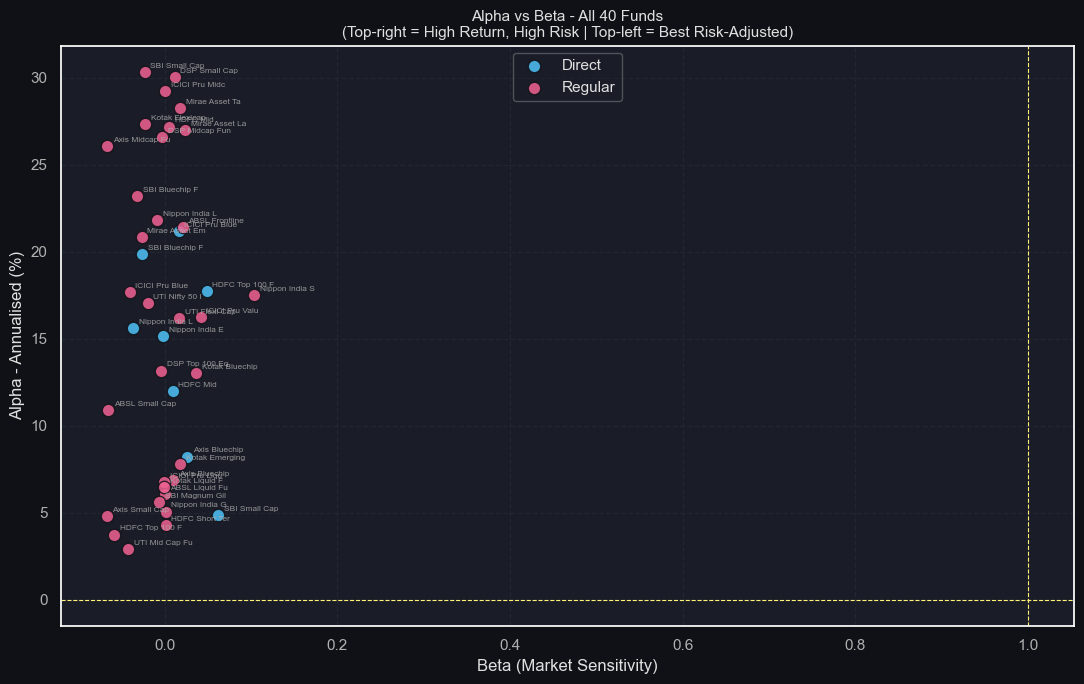

In [12]:
# Alpha vs Beta scatter
ab_plot = ab_df.dropna(subset=["alpha", "beta"])

color_map2 = {
    "Direct": "#4fc3f7",
    "Regular": "#f06292"
}

fig, ax = plt.subplots(figsize=(11, 7))

for plan, grp in ab_plot.groupby("plan"):
    ax.scatter(
        grp["beta"],
        grp["alpha"] * 100,
        label=plan,
        color=color_map2.get(plan, "#ffffff"),
        s=80,
        alpha=0.85,
        edgecolors="#0f1117"
    )

    for _, row in grp.iterrows():
        short = str(row["scheme_name"]).split("-")[0].strip()[:14]
        ax.annotate(
            short,
            (row["beta"], row["alpha"] * 100),
            textcoords="offset points",
            xytext=(4, 3),
            fontsize=6,
            color="#b0b0b0",
            alpha=0.8
        )

ax.axhline(0, color="#fff176", linewidth=0.8, linestyle="--")
ax.axvline(1, color="#fff176", linewidth=0.8, linestyle="--")

ax.set_xlabel("Beta (Market Sensitivity)")
ax.set_ylabel("Alpha - Annualised (%)")

ax.set_title(
    "Alpha vs Beta - All 40 Funds\n"
    "(Top-right = High Return, High Risk | Top-left = Best Risk-Adjusted)",
    fontsize=11
)

ax.legend(framealpha=0.3)

plt.tight_layout()

save_fig(fig, "PA_05_alpha_beta.png")

plt.show()

---
## 6. Maximum Drawdown

Maximum Drawdown measures the worst peak-to-trough decline a fund experienced:

> **Drawdown = NAV / running_max(NAV) − 1**
> **Max Drawdown = min(Drawdown)**

It tells you the worst loss an investor would have suffered if they bought at the peak and sold at the worst point. Lower (less negative) is better.

In [13]:
dd_rows = []
for code in nav_df["amfi_code"].unique():
    fd = nav_df[nav_df["amfi_code"]==code][["date","nav"]].copy().sort_values("date")
    fd["running_max"] = fd["nav"].cummax()
    fd["drawdown"]    = fd["nav"] / fd["running_max"] - 1

    max_dd      = fd["drawdown"].min()
    max_dd_date = fd.loc[fd["drawdown"].idxmin(), "date"]

    # Find when the peak before this drawdown occurred
    trough_nav  = fd.loc[fd["drawdown"].idxmin(), "nav"]
    peak_before = fd[fd["date"] <= max_dd_date]
    peak_date   = peak_before.loc[peak_before["nav"].idxmax(), "date"]

    dd_rows.append({
        "amfi_code"   : code,
        "max_drawdown": round(max_dd, 4),
        "trough_date" : max_dd_date.strftime("%Y-%m-%d"),
        "peak_date"   : peak_date.strftime("%Y-%m-%d"),
    })

dd_df = pd.DataFrame(dd_rows).merge(
    fund_df[["amfi_code","scheme_name","plan","sub_category"]], on="amfi_code", how="left")

print("Worst Maximum Drawdowns:")
worst = dd_df.nsmallest(10, "max_drawdown")[["scheme_name","plan","max_drawdown","peak_date","trough_date"]]
worst["max_drawdown"] = worst["max_drawdown"].map(lambda x: f"{x*100:.2f}%")
print(worst.to_string(index=False))
print()
print("Best (smallest) Max Drawdowns:")
best = dd_df.nlargest(5, "max_drawdown")[["scheme_name","plan","max_drawdown"]]
best["max_drawdown"] = best["max_drawdown"].map(lambda x: f"{x*100:.2f}%")
print(best.to_string(index=False))

Worst Maximum Drawdowns:
                                   scheme_name    plan max_drawdown  peak_date trough_date
     SBI Small Cap Fund - Direct Plan - Growth  Direct      -52.57% 2023-01-17  2025-10-28
        Axis Small Cap Fund - Regular - Growth Regular      -51.68% 2025-05-22  2026-05-11
        ABSL Small Cap Fund - Regular - Growth Regular      -35.45% 2024-11-21  2026-05-11
         DSP Small Cap Fund - Regular - Growth Regular      -31.17% 2024-05-03  2025-01-03
    SBI Small Cap Fund - Regular Plan - Growth Regular      -28.71% 2024-08-28  2025-05-14
           UTI Mid Cap Fund - Regular - Growth Regular      -28.00% 2025-01-07  2026-04-27
     HDFC Top 100 Fund - Regular Plan - Growth Regular      -24.73% 2022-03-30  2022-09-15
 Kotak Emerging Equity Fund - Regular - Growth Regular      -24.00% 2023-11-09  2024-10-17
Nippon India Small Cap Fund - Regular - Growth Regular      -23.34% 2025-04-09  2026-02-20
          Axis Bluechip Fund - Direct - Growth  Direct      -21.7

  Saved: C:\Users\Manis\OneDrive\Desktop\bluestock_mf_analysis\notebooks\charts\PA_06_max_drawdown.png


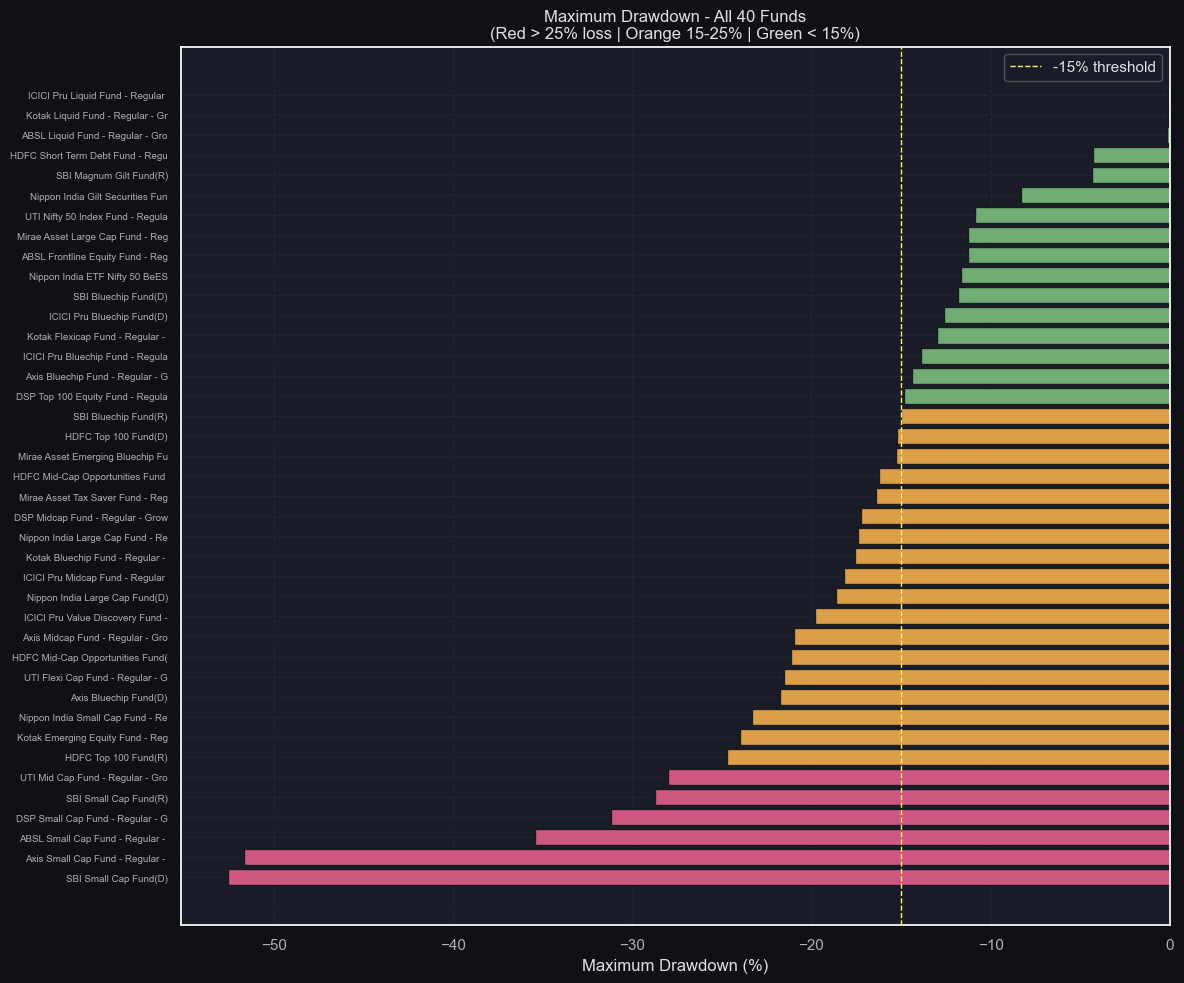

In [16]:
# Max drawdown bar chart
dd_plot = dd_df.sort_values("max_drawdown")

short = (
    dd_plot["scheme_name"]
    .str.replace(" - Direct Plan - Growth", "(D)")
    .str.replace(" - Regular Plan - Growth", "(R)")
    .str.replace(" - Direct - Growth", "(D)")
    .str[:32]
)

colors = [
    "#f06292" if d < -0.25
    else "#ffb74d" if d < -0.15
    else "#81c784"
    for d in dd_plot["max_drawdown"]
]

fig, ax = plt.subplots(figsize=(12, 10))

ax.barh(
    range(len(dd_plot)),
    dd_plot["max_drawdown"] * 100,
    color=colors,
    alpha=0.85,
    edgecolor="#0f1117"
)

ax.set_yticks(range(len(dd_plot)))
ax.set_yticklabels(short, fontsize=7)

ax.axvline(
    -15,
    color="#fff176",
    linewidth=1,
    linestyle="--",
    label="-15% threshold"
)

ax.set_xlabel("Maximum Drawdown (%)")

ax.set_title(
    "Maximum Drawdown - All 40 Funds\n"
    "(Red > 25% loss | Orange 15-25% | Green < 15%)",
    fontsize=12
)

ax.legend(framealpha=0.3)

plt.tight_layout()

save_fig(fig, "PA_06_max_drawdown.png")

plt.show()

---
## 7. Fund Scorecard (0–100)

A composite score combining five metrics with the following weights:

| Metric | Weight | Direction |
|--------|--------|-----------|
| 3-Year CAGR rank | 30% | Higher is better |
| Sharpe Ratio rank | 25% | Higher is better |
| Alpha rank | 20% | Higher is better |
| Expense Ratio rank | 15% | Lower is better (inverse) |
| Max Drawdown rank | 10% | Less negative is better (inverse) |

Each metric is ranked from 1 (worst) to N (best), then normalised to 0–100.

In [17]:
# Merge all metrics
scorecard = (cagr_df[["amfi_code","cagr_3yr"]]
    .merge(sharpe_df[["amfi_code","sharpe"]], on="amfi_code")
    .merge(ab_df[["amfi_code","alpha"]], on="amfi_code")
    .merge(dd_df[["amfi_code","max_drawdown"]], on="amfi_code")
    .merge(fund_df[["amfi_code","scheme_name","plan","sub_category","fund_house","expense_ratio_pct"]], on="amfi_code")
)
scorecard = scorecard.dropna(subset=["cagr_3yr","sharpe","alpha","max_drawdown","expense_ratio_pct"])
n = len(scorecard)

def rank_norm(series, ascending=True):
    """Rank and normalise to 0-100."""
    r = series.rank(ascending=ascending)
    return ((r - 1) / (n - 1) * 100).round(2)

scorecard["score_cagr"]     = rank_norm(scorecard["cagr_3yr"],        ascending=True)
scorecard["score_sharpe"]   = rank_norm(scorecard["sharpe"],           ascending=True)
scorecard["score_alpha"]    = rank_norm(scorecard["alpha"],            ascending=True)
scorecard["score_expense"]  = rank_norm(scorecard["expense_ratio_pct"],ascending=False)  # lower = better
scorecard["score_drawdown"] = rank_norm(scorecard["max_drawdown"],     ascending=False)  # less negative = better

scorecard["composite_score"] = (
    0.30 * scorecard["score_cagr"]    +
    0.25 * scorecard["score_sharpe"]  +
    0.20 * scorecard["score_alpha"]   +
    0.15 * scorecard["score_expense"] +
    0.10 * scorecard["score_drawdown"]
).round(2)

scorecard = scorecard.sort_values("composite_score", ascending=False).reset_index(drop=True)
scorecard["rank"] = scorecard.index + 1

print("TOP 10 FUNDS BY COMPOSITE SCORECARD:")
display_cols = ["rank","scheme_name","plan","composite_score","cagr_3yr","sharpe","alpha"]
top10_sc = scorecard[display_cols].head(10).copy()
top10_sc["cagr_3yr"] = top10_sc["cagr_3yr"].map(lambda x: f"{x*100:.1f}%")
top10_sc["alpha"]    = top10_sc["alpha"].map(lambda x: f"{x*100:.1f}%")
top10_sc["sharpe"]   = top10_sc["sharpe"].map(lambda x: f"{x:.2f}")
print(top10_sc.to_string(index=False))

# Save scorecard
out_path = os.path.join(BASE, "data", "processed", "fund_scorecard.csv")
scorecard.to_csv(out_path, index=False)
print(f"\nSaved: fund_scorecard.csv ({len(scorecard)} funds)")

TOP 10 FUNDS BY COMPOSITE SCORECARD:
 rank                                        scheme_name    plan  composite_score cagr_3yr sharpe alpha
    1           ICICI Pru Midcap Fund - Regular - Growth Regular            84.74    31.8%   0.88 29.3%
    2                Axis Midcap Fund - Regular - Growth Regular            81.54    35.1%   0.73 26.1%
    3 HDFC Mid-Cap Opportunities Fund - Regular - Growth Regular            80.00    32.4%   0.81 27.2%
    4      Mirae Asset Large Cap Fund - Regular - Growth Regular            79.49    34.0%   1.07 27.0%
    5             Kotak Flexicap Fund - Regular - Growth Regular            77.69    29.6%   0.97 27.3%
    6         SBI Small Cap Fund - Regular Plan - Growth Regular            75.13    26.7%   0.71 30.3%
    7              DSP Small Cap Fund - Regular - Growth Regular            74.94    27.0%   0.71 30.1%
    8          ICICI Pru Bluechip Fund - Direct - Growth  Direct            74.49    32.5%   0.71 21.2%
    9      Mirae Asset Tax 

  Saved: C:\Users\Manis\OneDrive\Desktop\bluestock_mf_analysis\notebooks\charts\PA_07_fund_scorecard.png


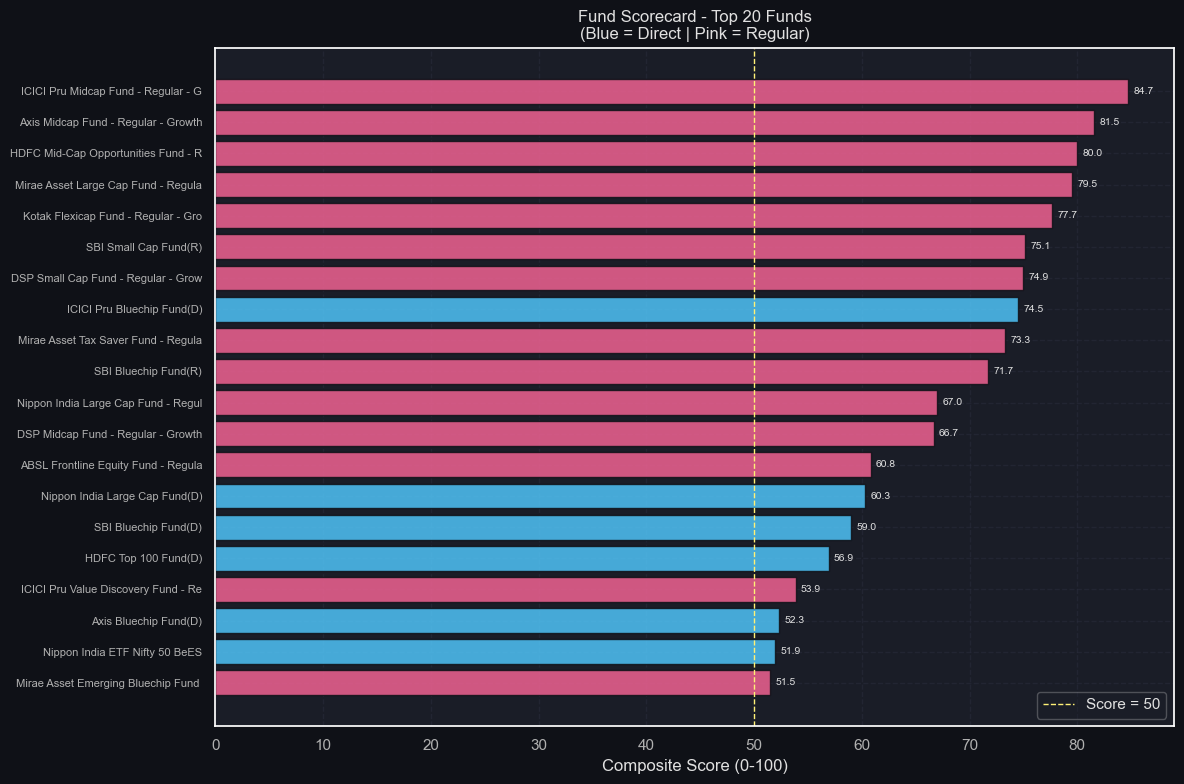

In [18]:
# Scorecard bar chart
top20 = scorecard.head(20)
short = top20["scheme_name"].str.replace(" - Direct Plan - Growth","(D)").str.replace(" - Regular Plan - Growth","(R)").str.replace(" - Direct - Growth","(D)").str[:35]
bar_colors = ["#4fc3f7" if p=="Direct" else "#f06292" for p in top20["plan"]]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top20))[::-1], top20["composite_score"], color=bar_colors, alpha=0.85, edgecolor="#0f1117")
ax.set_yticks(range(len(top20))[::-1])
ax.set_yticklabels(short, fontsize=8)
ax.set_xlabel("Composite Score (0-100)")
ax.set_title("Fund Scorecard - Top 20 Funds\n(Blue = Direct | Pink = Regular)", fontsize=12)
ax.axvline(50, color="#fff176", linewidth=1, linestyle="--", label="Score = 50")

for i, (bar, score) in enumerate(zip(bars, top20["composite_score"])):
    ax.text(score+0.5, bar.get_y()+bar.get_height()/2, f"{score:.1f}", va="center", fontsize=7.5, color="#e0e0e0")

ax.legend(framealpha=0.3)
plt.tight_layout()
save_fig(fig, "PA_07_fund_scorecard.png")

---
## 8. Benchmark Comparison — Top 5 Funds vs NIFTY 50 & NIFTY 100

We plot the top 5 scored funds against NIFTY 50 and NIFTY 100 over 3 years (all indexed to 100 at start). We also compute **Tracking Error** — the standard deviation of the difference between fund and benchmark returns, annualised:

> **Tracking Error = std(fund_return - benchmark_return) x sqrt(252)**

Lower tracking error = fund moves more closely with the index.

  Saved: C:\Users\Manis\OneDrive\Desktop\bluestock_mf_analysis\notebooks\charts\PA_08_benchmark_comparison.png


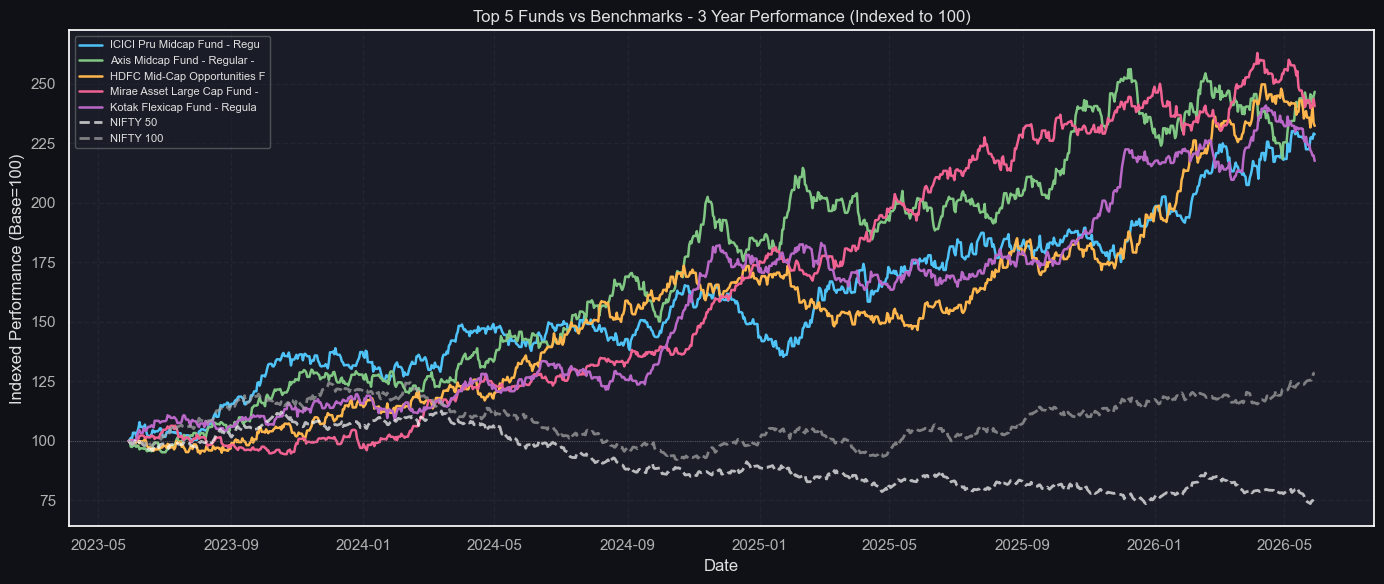


Tracking Error vs NIFTY 100:
                        Fund  Tracking Error vs NIFTY100 (%)
ICICI Pru Midcap Fund - Regu                           23.27
Axis Midcap Fund - Regular -                           23.98
HDFC Mid-Cap Opportunities F                           22.50
Mirae Asset Large Cap Fund -                           18.80
Kotak Flexicap Fund - Regula                           20.65


In [19]:
# Top 5 funds by scorecard
top5_codes = scorecard.head(5)["amfi_code"].tolist()
top5_names = dict(zip(scorecard.head(5)["amfi_code"],
                      scorecard.head(5)["scheme_name"].str.replace(" - Direct Plan - Growth","(D)").str.replace(" - Regular Plan - Growth","(R)").str[:28]))

# 3-year window
start_3yr = latest - pd.DateOffset(years=3)

n50  = bench_df[bench_df["index_name"]=="NIFTY50"].sort_values("date")
n100 = bench_df[bench_df["index_name"]=="NIFTY100"].sort_values("date")

fig, ax = plt.subplots(figsize=(14, 6))
colors_5 = ["#4fc3f7","#81c784","#ffb74d","#f06292","#ba68c8"]

te_rows = []
for i, code in enumerate(top5_codes):
    fd = nav_df[(nav_df["amfi_code"]==code) & (nav_df["date"]>=start_3yr)].copy()
    if len(fd) < 10: continue
    base = fd.iloc[0]["nav"]
    ax.plot(fd["date"], fd["nav"]/base*100, color=colors_5[i], linewidth=1.8,
            label=top5_names.get(code,str(code)))

    # Tracking error vs NIFTY 100
    fd_ret = fd[["date","daily_return"]].dropna()
    n100_ret = n100[n100["date"]>=start_3yr][["date"]].copy()
    n100_ret["bench_ret"] = n100[n100["date"]>=start_3yr]["close_value"].pct_change().values
    merged_te = fd_ret.merge(n100_ret, on="date").dropna()
    if len(merged_te) > 10:
        te = (merged_te["daily_return"] - merged_te["bench_ret"]).std() * np.sqrt(252) * 100
        te_rows.append({"Fund": top5_names.get(code,str(code)), "Tracking Error vs NIFTY100 (%)": round(te,2)})

# Plot benchmarks
for bdf, bname, bcol in [(n50,"NIFTY 50","#ffffff"),(n100,"NIFTY 100","#aaaaaa")]:
    b3 = bdf[bdf["date"]>=start_3yr]
    base_b = b3.iloc[0]["close_value"]
    ax.plot(b3["date"], b3["close_value"]/base_b*100, color=bcol, linewidth=2,
            linestyle="--", label=bname, alpha=0.7)

ax.set_title("Top 5 Funds vs Benchmarks - 3 Year Performance (Indexed to 100)", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Indexed Performance (Base=100)")
ax.legend(fontsize=8, framealpha=0.3)
ax.axhline(100, color="gray", linewidth=0.5, linestyle=":")
plt.tight_layout()
save_fig(fig, "PA_08_benchmark_comparison.png")

print("\nTracking Error vs NIFTY 100:")
te_df = pd.DataFrame(te_rows)
print(te_df.to_string(index=False))

---
## Summary — Day 4 Deliverables

| Deliverable | Description | Status |
|-------------|-------------|--------|
| Daily Returns | Computed for all 40 funds, distribution validated | Done |
| CAGR Table | 1yr, 3yr, 4yr CAGR for all funds | Done |
| Sharpe Ratio | Annualised, ranked all 40 funds | Done |
| Sortino Ratio | Downside-only risk measure | Done |
| Alpha & Beta | OLS regression vs NIFTY 100 | Done |
| Max Drawdown | Worst peak-to-trough with dates | Done |
| Fund Scorecard | Composite 0-100 score, saved as CSV | Done |
| Benchmark Chart | Top 5 funds vs NIFTY 50 & 100 with tracking error | Done |
| alpha_beta.csv | All alpha/beta values saved | Done |
| fund_scorecard.csv | Full ranked scorecard saved | Done |

**Risk-free rate used:** 6.5% per annum (RBI repo rate proxy)  
**Benchmark used for regression:** NIFTY 100  
**Data period:** Jan 2022 to May 2026